# Figure 4 — Landmark Preference Development

**Panel A** — Day 1 landmark preference heatmap (layer × landmark)  
**Panel B** — Day 7 landmark preference heatmap  
**Panel C** — Delta heatmap: Day 7 − Day 1  
**Panel D** — LD1 vs LD4 trajectory per layer across days

In [74]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import h5py

# ── Font ──────────────────────────────────────────────────────────────────────
mpl.rcParams['font.family']      = 'Arial'
mpl.rcParams['font.weight']      = 'normal'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'normal'

# ── CONFIG ────────────────────────────────────────────────────────────────────
PARENT_DIR      = r'D:\V1_SpatialModulation\2p\V1_prism'
LAYER_ORDER     = ['L2/3', 'L4', 'L5', 'L6']
LAYER_COLORS    = {'L2/3': '#1E88E5', 'L4': '#FF9800', 'L5': '#4CAF50', 'L6': '#E53935'}
LANDMARK_NAMES  = ['LD1', 'LD2', 'LD3', 'LD4']
LANDMARK_DISTANCES = ['25cm', '55cm', '85cm', '115cm']
LANDMARK_COLORS = {
    'LD1': '#E74C3C',   # red
    'LD2': '#8E44AD',   # purple
    'LD3': '#8B4513',   # brown
    'LD4': '#808080',   # gray
}
MAX_DAY         = 7

OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('')), 'Poster', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config loaded.')

Config loaded.


In [75]:
# Load landmark proportions for every animal × day × layer
# lm_by_animal[animal][day][layer] = np.array shape (4,) = [LD1, LD2, LD3, LD4] proportions

def extract_animal_day(filepath):
    m_a = re.search(r'(JSY\d+)', filepath)
    m_d = re.search(r'[Dd]ay(\d+)', filepath)
    return (m_a.group(1) if m_a else None,
            int(m_d.group(1)) if m_d else None)

lm_files = glob.glob(os.path.join(PARENT_DIR, '**', '*Day*_landmark_preferences.h5'), recursive=True)

lm_by_animal = {}   # animal → day → layer → np.array(4,)

for path in lm_files:
    animal, day = extract_animal_day(path)
    if animal is None or day is None or day > MAX_DAY:
        continue

    if animal not in lm_by_animal:
        lm_by_animal[animal] = {}
    if day not in lm_by_animal[animal]:
        lm_by_animal[animal][day] = {}

    with h5py.File(path, 'r') as f:
        if 'full_session' not in f:
            continue
        for lk in f['full_session'].keys():
            lg         = f['full_session'][lk]
            layer_name = lg.attrs.get('original_name', lk.replace('_', '/'))
            if layer_name not in LAYER_ORDER:
                continue
            if 'landmark_proportions' in lg:
                lm_by_animal[animal][day][layer_name] = lg['landmark_proportions'][:]

animals  = sorted(lm_by_animal.keys())
all_days = sorted({d for a in lm_by_animal.values() for d in a.keys()})
print(f'Animals : {animals}')
print(f'Days    : {all_days}')
for animal in animals:
    days_a = sorted(lm_by_animal[animal].keys())
    print(f'  {animal}: days {days_a}')

Animals : ['JSY040', 'JSY041', 'JSY044', 'JSY051', 'JSY052', 'JSY054', 'JSY055']
Days    : [1, 2, 3, 4, 5, 6, 7]
  JSY040: days [1, 3]
  JSY041: days [1, 3, 5, 7]
  JSY044: days [1, 2, 3, 4, 5, 6, 7]
  JSY051: days [1, 2, 3, 4, 5]
  JSY052: days [1, 2, 3, 4, 5, 6, 7]
  JSY054: days [1, 2, 3, 4, 5, 6, 7]
  JSY055: days [1, 2, 3, 4, 5, 6, 7]


In [76]:
# ── Animal selection ──────────────────────────────────────────────────────────
# Run the load cell first to see which animals are available, then edit this
# list to keep only the ones you want. Set to None to include all.

# INCLUDE_ANIMALS = ['JSY040','JSY041','JSY044','JSY052','JSY051','JSY054','JSY055']
INCLUDE_ANIMALS = ['JSY040','JSY052','JSY051','JSY054','JSY055']

# ─────────────────────────────────────────────────────────────────────────────
if INCLUDE_ANIMALS is not None:
    excluded = [a for a in animals if a not in INCLUDE_ANIMALS]
    animals  = [a for a in animals if a in INCLUDE_ANIMALS]
    for a in excluded:
        lm_by_animal.pop(a, None)
    print(f'Using animals : {animals}')
    print(f'Excluded      : {excluded}')
else:
    print(f'Using all animals: {animals}')

Using animals : ['JSY040', 'JSY051', 'JSY052', 'JSY054', 'JSY055']
Excluded      : ['JSY041', 'JSY044']


Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\Poster\output\panel_A_LM_day1.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\Poster\output\panel_A_LM_day1.png


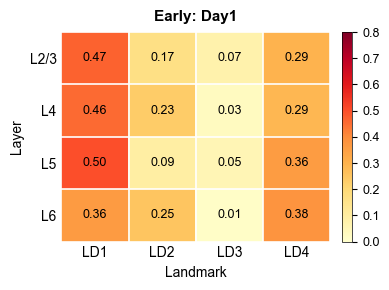

In [77]:
# Panel A — Day 1 landmark preference heatmap
# Rows: L2/3, L4, L5, L6  |  Cols: L1, L2, L3, L4
# Values: mean proportion across animals on Day 1

def build_heatmap_matrix(day):
    """Build 4×4 matrix (layer × landmark) averaged across animals for a given day."""
    mat = np.full((len(LAYER_ORDER), len(LANDMARK_NAMES)), np.nan)
    for li, layer in enumerate(LAYER_ORDER):
        vals = []
        for animal in animals:
            if day in lm_by_animal.get(animal, {}) and layer in lm_by_animal[animal][day]:
                vals.append(lm_by_animal[animal][day][layer])
        if vals:
            mat[li] = np.mean(vals, axis=0)
    return mat

def plot_lm_heatmap(ax, mat, title_str, vmin=0.0, vmax=1.0, cmap='YlOrRd', annotate_sign=False):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax,
                   aspect='auto', interpolation='nearest')
    for li in range(len(LAYER_ORDER)):
        for lmi in range(len(LANDMARK_NAMES)):
            val = mat[li, lmi]
            if np.isnan(val):
                continue
            txt = f'{val:+.2f}' if annotate_sign else f'{val:.2f}'
            # Use white text on dark cells, black on light cells
            mid = (vmax + vmin) / 2
            if annotate_sign:
                fc = 'white' if abs(val) > abs(vmax) * 0.65 else 'black'
            else:
                fc = 'white' if val > mid + (vmax - vmin) * 0.25 else 'black'
            ax.text(lmi, li, txt, ha='center', va='center',
                    fontsize=9, color=fc, fontfamily='Arial')
    for x in np.arange(-0.5, len(LANDMARK_NAMES), 1):
        ax.axvline(x, color='white', lw=1.2)
    for y in np.arange(-0.5, len(LAYER_ORDER), 1):
        ax.axhline(y, color='white', lw=1.2)
    ax.set_xticks(range(len(LANDMARK_NAMES)))
    ax.set_xticklabels(LANDMARK_NAMES, fontsize=10)
    ax.set_yticks(range(len(LAYER_ORDER)))
    ax.set_yticklabels(LAYER_ORDER, fontsize=10)
    ax.tick_params(axis='both', length=0, width=0)
    ax.spines[:].set_visible(False)
    ax.set_title(title_str, fontsize=11, fontweight='bold', pad=8)
    return im

mat_day1 = build_heatmap_matrix(day=1)

fig_a, ax = plt.subplots(figsize=(4.0, 3.0))
im = plot_lm_heatmap(ax, mat_day1, 'Early: Day1', vmin=0.0, vmax=0.8)
ax.set_xlabel('Landmark', fontsize=10)
ax.set_ylabel('Layer', fontsize=10)
cbar = fig_a.colorbar(im, ax=ax, fraction=0.046, pad=0.04, aspect=20)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0.5)
plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'panel_A_LM_day1{ext}')
    fig_a.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\Poster\output\panel_B_LM_day7.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\Poster\output\panel_B_LM_day7.png


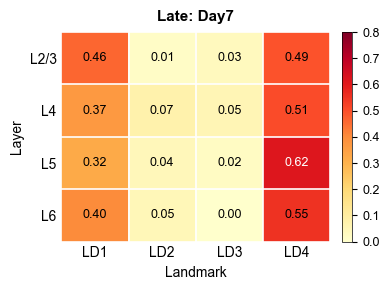

In [78]:
# Panel B — Day 7 landmark preference heatmap (same format/scale as Panel A)

mat_day7 = build_heatmap_matrix(day=7)

fig_b, ax = plt.subplots(figsize=(4.0, 3.0))
im = plot_lm_heatmap(ax, mat_day7, 'Late: Day7', vmin=0.0, vmax=0.8)
ax.set_xlabel('Landmark', fontsize=10)
ax.set_ylabel('Layer', fontsize=10)
cbar = fig_b.colorbar(im, ax=ax, fraction=0.046, pad=0.04, aspect=20)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0.5)
plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'panel_B_LM_day7{ext}')
    fig_b.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\Poster\output\panel_C_LM_delta.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\Poster\output\panel_C_LM_delta.png


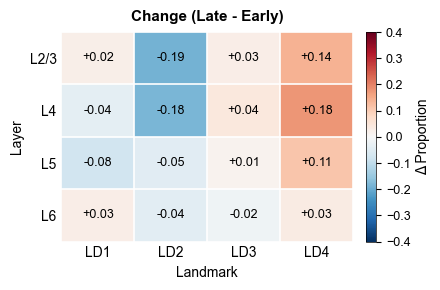

In [79]:
# Panel C — Delta heatmap: Late − Early (Day 7 − Day 1)
# Only animals with both Day 1 and Day 7 data are included.
# Blue = decreased, Red = increased.

delta_mat = np.full((len(LAYER_ORDER), len(LANDMARK_NAMES)), np.nan)

for li, layer in enumerate(LAYER_ORDER):
    deltas = []
    for animal in animals:
        ad = lm_by_animal.get(animal, {})
        if 1 in ad and 7 in ad and layer in ad[1] and layer in ad[7]:
            deltas.append(ad[7][layer] - ad[1][layer])
    if deltas:
        delta_mat[li] = np.mean(deltas, axis=0)

fig_c, ax = plt.subplots(figsize=(4.5, 3.0))
im = plot_lm_heatmap(ax, delta_mat, 'Change (Late - Early)',
                     vmin=-0.4, vmax=0.4,
                     cmap='RdBu_r',
                     annotate_sign=True)
ax.set_xlabel('Landmark', fontsize=10)
ax.set_ylabel('Layer', fontsize=10)
cbar = fig_c.colorbar(im, ax=ax, fraction=0.046, pad=0.04, aspect=20)
cbar.set_label('Δ Proportion', fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0.5)
plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'panel_C_LM_delta{ext}')
    fig_c.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_77544\498275006.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\Poster\output\panel_D_LM_trajectories.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\Poster\output\panel_D_LM_trajectories.png


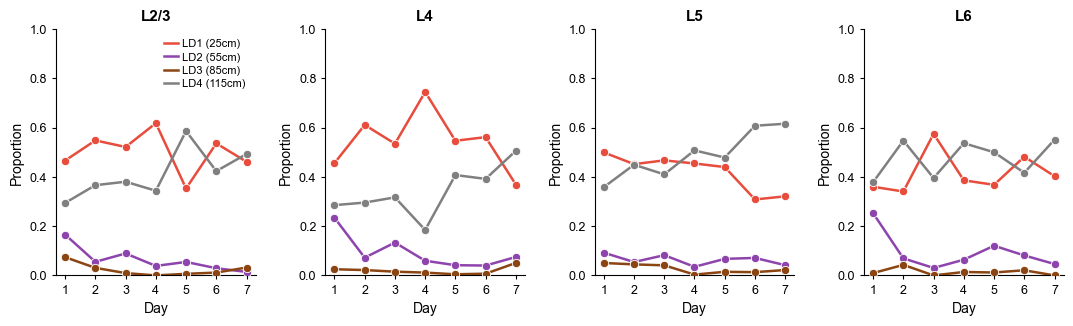

In [80]:
# Panel D — All landmark trajectories per layer across days
# 1×4 grid of subplots, one per cortical layer
# All 4 landmarks plotted per subplot, each with its own color

# Build per-layer, per-landmark, per-animal, per-day data
ALL_LM_IDX = list(range(len(LANDMARK_NAMES)))

by_day    = {l: {i: {d: [] for d in all_days} for i in ALL_LM_IDX} for l in LAYER_ORDER}
by_animal = {l: {i: {a: {} for a in animals}  for i in ALL_LM_IDX} for l in LAYER_ORDER}

for animal in animals:
    for day in all_days:
        if day not in lm_by_animal.get(animal, {}):
            continue
        for layer in LAYER_ORDER:
            if layer not in lm_by_animal[animal][day]:
                continue
            props = lm_by_animal[animal][day][layer]
            for idx in ALL_LM_IDX:
                val = props[idx]
                by_day[layer][idx][day].append(val)
                by_animal[layer][idx][animal][day] = val

fig_d, axes = plt.subplots(1, 4, figsize=(13, 3.2),
                            gridspec_kw={'wspace': 0.35})

for ax, layer in zip(axes.flat, LAYER_ORDER):
    for lm_idx, lm_name in enumerate(LANDMARK_NAMES):
        color = LANDMARK_COLORS[lm_name]
        dist  = LANDMARK_DISTANCES[lm_idx]
        label = f'{lm_name} ({dist})'

        # Mean ± SD across animals
        xs, ys, sds = [], [], []
        for day in all_days:
            vals = by_day[layer][lm_idx][day]
            if not vals:
                continue
            xs.append(day)
            ys.append(np.mean(vals))
            sds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)
        xs   = np.array(xs)
        ys   = np.array(ys)
        sds  = np.array(sds)

        # ax.fill_between(xs, ys - sds, ys + sds, color=color, alpha=0.20, zorder=2)
        ax.plot(xs, ys, color=color, lw=1.8, zorder=3, label=label)
        ax.scatter(xs, ys, color=color, s=6**2, marker='o', zorder=4,
                   edgecolors='white', linewidths=0.6)

    ax.set_title(layer, fontsize=11, fontweight='bold', pad=6)
    ax.set_xticks(all_days)
    ax.set_xlim(all_days[0] - 0.3, all_days[-1] + 0.3)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlabel('Day', fontsize=10)
    ax.set_ylabel('Proportion', fontsize=10)
    ax.tick_params(axis='both', labelsize=9, length=3, width=0.8)
    # ax.yaxis.grid(True, color='#CCCCCC', lw=0.5, zorder=0)
    # ax.xaxis.grid(True, color='#CCCCCC', lw=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(0.8)

    # Legend only on first subplot
    if layer == LAYER_ORDER[0]:
        ax.legend(fontsize=8, frameon=False, loc='upper right',
                  handlelength=1.2, handletextpad=0.4, labelspacing=0.3)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'panel_D_LM_trajectories{ext}')
    fig_d.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_77544\2498769718.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


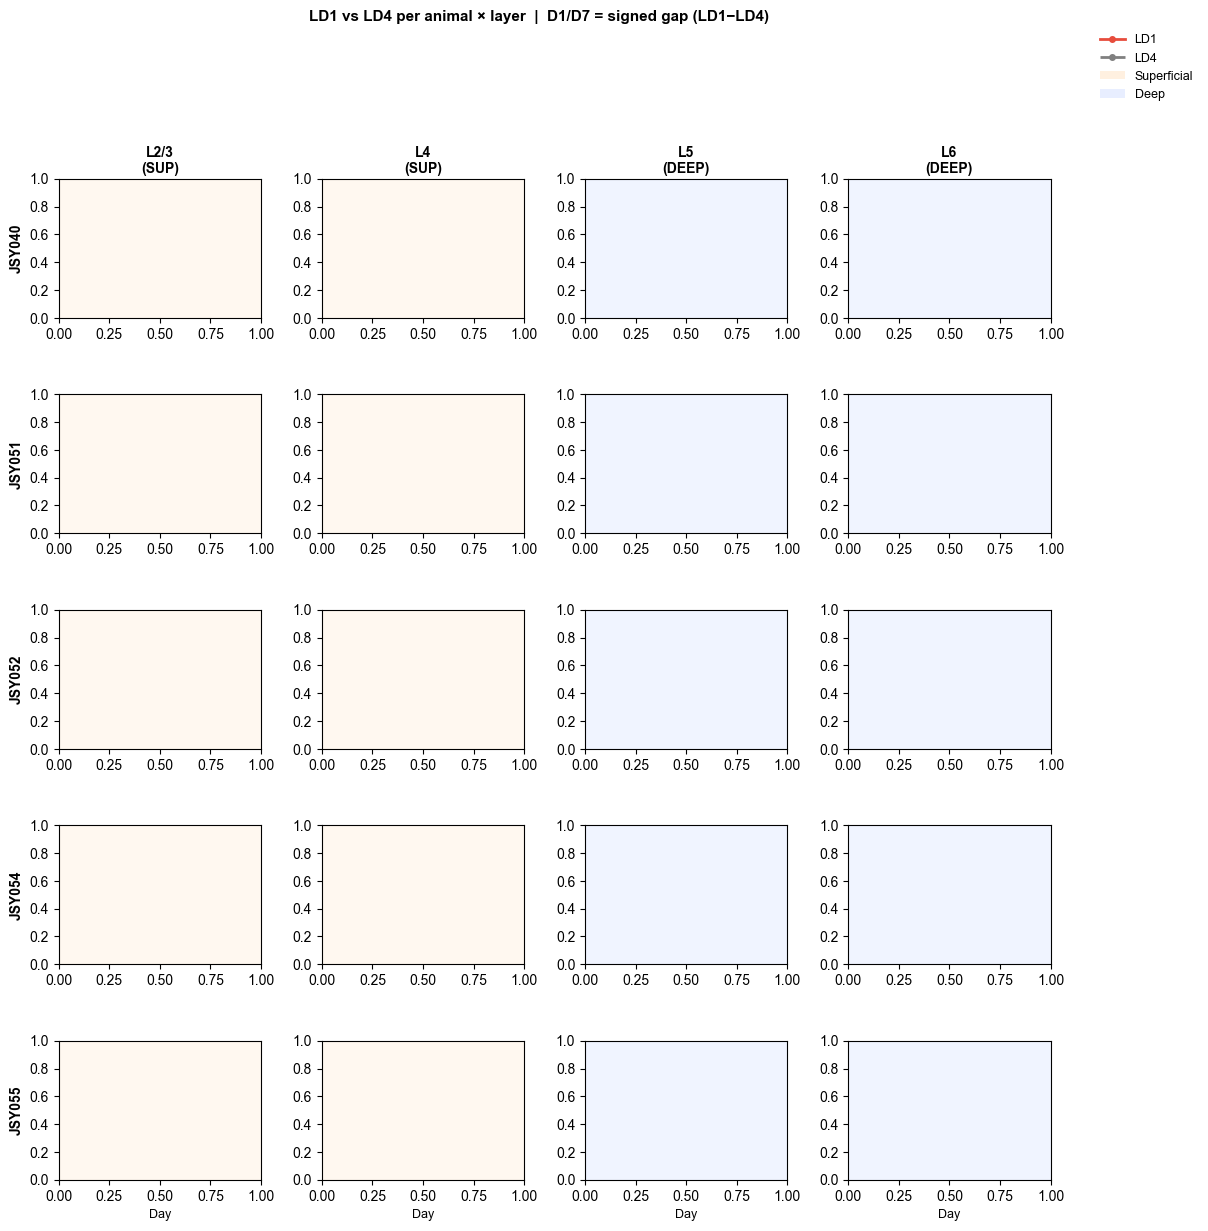

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_77544\2498769718.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


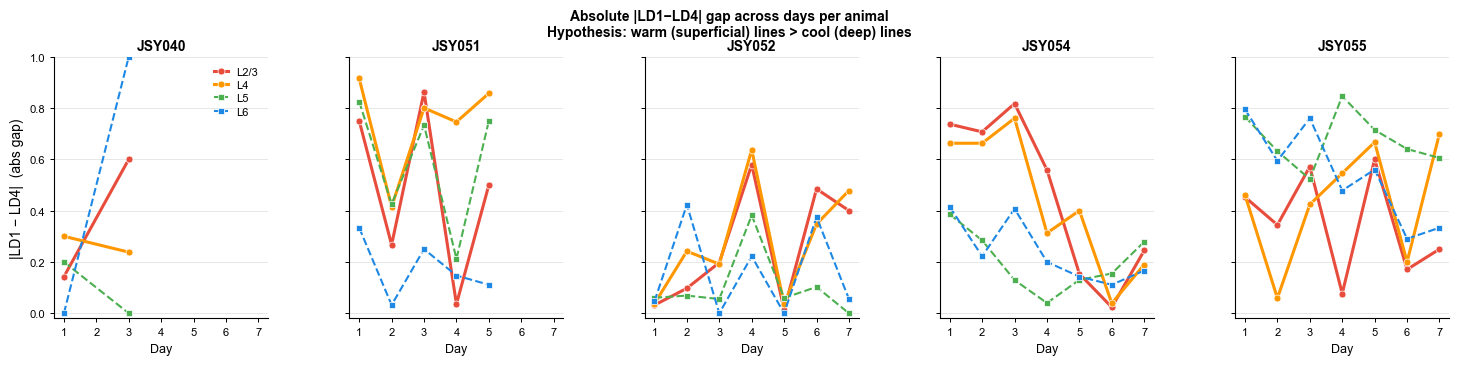

C:\Users\jasmineyeo\AppData\Local\Temp\ipykernel_77544\2498769718.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


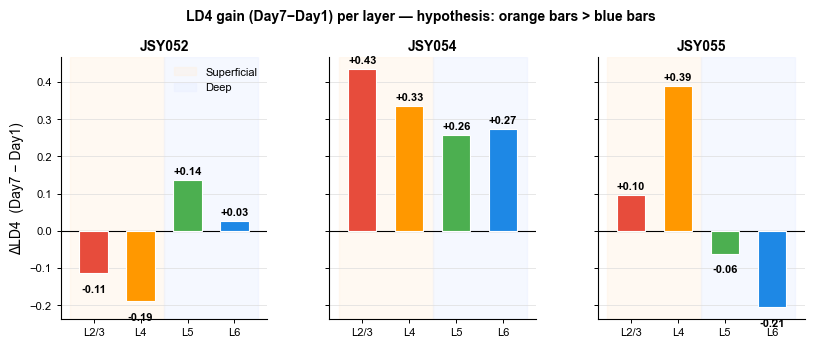

REFINED HYPOTHESIS SCORING
Criteria:
  [A] |LD1-LD4| abs gap at Day7:  superficial avg > deep avg
  [B] LD4 gain (Day7-Day1):        superficial avg > deep avg
  [C] LD4 proportion at Day7:      superficial avg > deep avg  (LD4 dominates superficial)

  JSY040
    L2/3 (SUP)  abs_gap_D7=+nan  LD4_gain=+nan  LD4_D7=nan
    L4 (SUP)  abs_gap_D7=+nan  LD4_gain=+nan  LD4_D7=nan
    L5 (DEEP)  abs_gap_D7=+nan  LD4_gain=+nan  LD4_D7=nan
    L6 (DEEP)  abs_gap_D7=+nan  LD4_gain=+nan  LD4_D7=nan
  [A] abs gap:  sup=nan vs deep=nan  → ✗
  [B] LD4 gain: sup=nan vs deep=nan  → ✗
  [C] LD4 D7:   sup=nan  vs deep=nan   → ✗
  ➜  ✗ no fit

  JSY051
    L2/3 (SUP)  abs_gap_D7=+nan  LD4_gain=+nan  LD4_D7=nan
    L4 (SUP)  abs_gap_D7=+nan  LD4_gain=+nan  LD4_D7=nan
    L5 (DEEP)  abs_gap_D7=+nan  LD4_gain=+nan  LD4_D7=nan
    L6 (DEEP)  abs_gap_D7=+nan  LD4_gain=+nan  LD4_D7=nan
  [A] abs gap:  sup=nan vs deep=nan  → ✗
  [B] LD4 gain: sup=nan vs deep=nan  → ✗
  [C] LD4 D7:   sup=nan  vs deep=nan   → ✗
 

In [81]:
# ══════════════════════════════════════════════════════════════════════════════
# HYPOTHESIS EXPLORER
# Hypothesis: by Day 7 —
#   • Superficial (L2/3, L4): LARGER |LD1-LD4| gap AND preference shifted to LD4
#   • Deep (L5, L6): SMALLER |LD1-LD4| gap (more uniform)
#   • The LD4 gain (ΔLD4 = Day7 - Day1) should be LARGER in superficial than deep
#
# Figure 1 — Per-animal LD1 vs LD4 trajectories (rows=animals, cols=layers)
# Figure 2 — |LD1-LD4| absolute gap per layer across days (depth gradient view)
# Figure 3 — ΔLD4 gain (Day7-Day1) per layer: bar chart per animal
# Print     — Refined scoring using absolute gap + LD4 gain gradient
# ══════════════════════════════════════════════════════════════════════════════

LD1_IDX = 0
LD4_IDX = 3
SUPERFICIAL = ['L2/3', 'L4']
DEEP        = ['L5',   'L6']

def get_ld1_ld4(animal, layer):
    days_out, ld1_out, ld4_out = [], [], []
    for d in sorted(lm_by_animal.get(animal, {}).keys()):
        if layer in lm_by_animal[animal][d]:
            p = lm_by_animal[animal][d][layer]
            days_out.append(d)
            ld1_out.append(p[LD1_IDX])
            ld4_out.append(p[LD4_IDX])
    return np.array(days_out), np.array(ld1_out), np.array(ld4_out)

ANIMAL_CMAP   = plt.cm.tab10
animal_colors = {a: ANIMAL_CMAP(i / max(len(animals) - 1, 1))
                 for i, a in enumerate(animals)}
n_animals = len(animals)
n_layers  = len(LAYER_ORDER)

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — per-animal LD1 vs LD4 grid
# ══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(n_animals, n_layers,
                            figsize=(3.2 * n_layers, 2.6 * n_animals),
                            gridspec_kw={'wspace': 0.30, 'hspace': 0.55})
if n_animals == 1:
    axes1 = axes1[np.newaxis, :]

for ai, animal in enumerate(animals):
    for li, layer in enumerate(LAYER_ORDER):
        ax = axes1[ai, li]
        days, ld1, ld4 = get_ld1_ld4(animal, layer)
        depth_label = 'SUP' if layer in SUPERFICIAL else 'DEEP'
        bg_color    = '#FFF8F0' if layer in SUPERFICIAL else '#F0F4FF'
        ax.set_facecolor(bg_color)

        if len(days) == 0:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            ax.spines[:].set_visible(False)
        # else:
        #     ax.fill_between(days, ld1, ld4,
        #                     where=(ld1 >= ld4), color='#E74C3C', alpha=0.20, lw=0)
        #     ax.fill_between(days, ld1, ld4,
        #                     where=(ld1 < ld4),  color='#808080', alpha=0.20, lw=0)
        #     ax.plot(days, ld1, color='#E74C3C', lw=2.0, marker='o',
        #             markersize=5, markeredgecolor='white', markeredgewidth=0.6, zorder=3)
        #     ax.plot(days, ld4, color='#808080', lw=2.0, marker='o',
        #             markersize=5, markeredgecolor='white', markeredgewidth=0.6,
        #             linestyle='--', zorder=3)

            ad = lm_by_animal[animal]
            if 1 in ad and layer in ad[1]:
                g1 = ad[1][layer][LD1_IDX] - ad[1][layer][LD4_IDX]
                ax.text(0.04, 0.97, f'D1:{g1:+.2f}',
                        transform=ax.transAxes, fontsize=7, va='top', color='#666666')
            if 7 in ad and layer in ad[7]:
                g7 = ad[7][layer][LD1_IDX] - ad[7][layer][LD4_IDX]
                ax.text(0.97, 0.97, f'D7:{g7:+.2f}',
                        transform=ax.transAxes, fontsize=7, va='top', ha='right',
                        color='#222222', fontweight='bold')

            ax.set_xticks(all_days)
            ax.set_xlim(all_days[0] - 0.3, all_days[-1] + 0.3)
            ax.set_ylim(-0.05, 1.05)
            ax.set_yticks([0, 0.5, 1.0])
            ax.tick_params(labelsize=8, length=2, width=0.7)
            ax.yaxis.grid(True, color='#DDDDDD', lw=0.5, zorder=0)
            ax.set_axisbelow(True)
            ax.spines[['top', 'right']].set_visible(False)
            ax.spines[['left', 'bottom']].set_linewidth(0.7)

        if ai == 0:
            ax.set_title(f'{layer}\n({depth_label})', fontsize=10, fontweight='bold', pad=4)
        if li == 0:
            ax.set_ylabel(animal, fontsize=10, fontweight='bold', rotation=90, labelpad=4)
        if ai == n_animals - 1:
            ax.set_xlabel('Day', fontsize=9)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
leg_els = [
    Line2D([0], [0], color='#E74C3C', lw=2, marker='o', markersize=4, label='LD1'),
    Line2D([0], [0], color='#808080', lw=2, marker='o', markersize=4, ls='--', label='LD4'),
    Patch(facecolor='#FFF0E0', label='Superficial'),
    Patch(facecolor='#E8EEFF', label='Deep'),
]
fig1.legend(handles=leg_els, fontsize=9, frameon=False,
            loc='upper right', bbox_to_anchor=(1.02, 1.0), ncol=1)
fig1.suptitle('LD1 vs LD4 per animal × layer  |  D1/D7 = signed gap (LD1−LD4)',
              fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
for ext in ('.svg', '.png'):
    fig1.savefig(os.path.join(OUTPUT_DIR, f'hyp_per_animal_LD1vsLD4{ext}'),
                 dpi=200, bbox_inches='tight', format=ext.lstrip('.'))
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — ABSOLUTE |LD1-LD4| gap per layer across days
#            Hypothesis: superficial (warm) should be ABOVE deep (cool) lines
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, n_animals, figsize=(3.6 * n_animals, 3.4),
                            gridspec_kw={'wspace': 0.38}, sharey=True)
if n_animals == 1:
    axes2 = [axes2]

layer_styles = {
    'L2/3': dict(color='#E74C3C', lw=2.2, ls='-',  marker='o'),
    'L4':   dict(color='#FF9800', lw=2.2, ls='-',  marker='o'),
    'L5':   dict(color='#4CAF50', lw=1.5, ls='--', marker='s'),
    'L6':   dict(color='#1E88E5', lw=1.5, ls='--', marker='s'),
}

for ai, (ax, animal) in enumerate(zip(axes2, animals)):
    for layer in LAYER_ORDER:
        days, ld1, ld4 = get_ld1_ld4(animal, layer)
        if len(days) == 0:
            continue
        abs_gap = np.abs(ld1 - ld4)
        st = layer_styles[layer]
        ax.plot(days, abs_gap, color=st['color'], lw=st['lw'], ls=st['ls'],
                marker=st['marker'], markersize=5,
                markeredgecolor='white', markeredgewidth=0.5,
                label=layer, zorder=3)

    ax.set_title(animal, fontsize=10, fontweight='bold', pad=5)
    ax.set_xticks(all_days)
    ax.set_xlim(all_days[0] - 0.3, all_days[-1] + 0.3)
    ax.set_ylim(-0.02, 1.0)
    ax.tick_params(labelsize=8, length=3, width=0.7)
    ax.yaxis.grid(True, color='#DDDDDD', lw=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(0.8)
    ax.set_xlabel('Day', fontsize=9)
    if ai == 0:
        ax.set_ylabel('|LD1 − LD4|  (abs gap)', fontsize=10)
    if ai == 0:
        ax.legend(fontsize=8, frameon=False, loc='upper right',
                  handlelength=1.2, labelspacing=0.3)

fig2.suptitle('Absolute |LD1−LD4| gap across days per animal\n'
              'Hypothesis: warm (superficial) lines > cool (deep) lines',
              fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
for ext in ('.svg', '.png'):
    fig2.savefig(os.path.join(OUTPUT_DIR, f'hyp_abs_gap_by_layer{ext}'),
                 dpi=200, bbox_inches='tight', format=ext.lstrip('.'))
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — ΔLD4 gain (Day7 − Day1) per layer: grouped bar chart per animal
#            Hypothesis: superficial bars should be TALLER (more LD4 gain)
# ══════════════════════════════════════════════════════════════════════════════
complete_animals = [a for a in animals
                    if 1 in lm_by_animal.get(a, {}) and 7 in lm_by_animal.get(a, {})]

fig3, axes3 = plt.subplots(1, len(complete_animals),
                            figsize=(3.2 * len(complete_animals), 3.4),
                            sharey=True, gridspec_kw={'wspace': 0.30})
if len(complete_animals) == 1:
    axes3 = [axes3]

bar_colors = [layer_styles[l]['color'] for l in LAYER_ORDER]
x = np.arange(len(LAYER_ORDER))

for ax, animal in zip(axes3, complete_animals):
    ad = lm_by_animal[animal]
    delta_ld4 = []
    for layer in LAYER_ORDER:
        if layer in ad[1] and layer in ad[7]:
            delta_ld4.append(ad[7][layer][LD4_IDX] - ad[1][layer][LD4_IDX])
        else:
            delta_ld4.append(np.nan)

    bars = ax.bar(x, delta_ld4, color=bar_colors, width=0.6,
                  edgecolor='white', linewidth=0.8, zorder=3)
    for bar, val in zip(bars, delta_ld4):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01 if val >= 0 else val - 0.03,
                    f'{val:+.2f}', ha='center', va='bottom' if val >= 0 else 'top',
                    fontsize=8, fontweight='bold')

    ax.axhline(0, color='black', lw=0.8, zorder=2)
    ax.axvspan(-0.5, 1.5, color='#FFF0E0', alpha=0.4, zorder=0, label='Superficial')
    ax.axvspan(1.5, 3.5, color='#E8EEFF', alpha=0.4, zorder=0, label='Deep')
    ax.set_title(animal, fontsize=10, fontweight='bold', pad=5)
    ax.set_xticks(x)
    ax.set_xticklabels(LAYER_ORDER, fontsize=9)
    ax.tick_params(labelsize=8, length=3, width=0.7)
    ax.yaxis.grid(True, color='#DDDDDD', lw=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)
    if ax is axes3[0]:
        ax.set_ylabel('ΔLD4  (Day7 − Day1)', fontsize=10)
        ax.legend(fontsize=8, frameon=False, loc='upper right')

fig3.suptitle('LD4 gain (Day7−Day1) per layer — hypothesis: orange bars > blue bars',
              fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
for ext in ('.svg', '.png'):
    fig3.savefig(os.path.join(OUTPUT_DIR, f'hyp_LD4_gain_by_layer{ext}'),
                 dpi=200, bbox_inches='tight', format=ext.lstrip('.'))
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# REFINED SCORING — absolute gap + LD4 gain gradient
# ══════════════════════════════════════════════════════════════════════════════
print('REFINED HYPOTHESIS SCORING')
print('Criteria:')
print('  [A] |LD1-LD4| abs gap at Day7:  superficial avg > deep avg')
print('  [B] LD4 gain (Day7-Day1):        superficial avg > deep avg')
print('  [C] LD4 proportion at Day7:      superficial avg > deep avg  (LD4 dominates superficial)')
print('=' * 72)

scores = {}
for animal in animals:
    ad = lm_by_animal.get(animal, {})
    has_d1, has_d7 = (1 in ad), (7 in ad)

    sup_abs_d7, deep_abs_d7 = [], []
    sup_ld4_gain, deep_ld4_gain = [], []
    sup_ld4_d7, deep_ld4_d7 = [], []

    print(f'\n  {animal}')
    for layer in LAYER_ORDER:
        d1_ld1 = ad[1][layer][LD1_IDX] if (has_d1 and layer in ad[1]) else np.nan
        d1_ld4 = ad[1][layer][LD4_IDX] if (has_d1 and layer in ad[1]) else np.nan
        d7_ld1 = ad[7][layer][LD1_IDX] if (has_d7 and layer in ad[7]) else np.nan
        d7_ld4 = ad[7][layer][LD4_IDX] if (has_d7 and layer in ad[7]) else np.nan

        abs_gap_d7 = abs(d7_ld1 - d7_ld4) if not np.isnan(d7_ld1) else np.nan
        ld4_gain   = d7_ld4 - d1_ld4       if not (np.isnan(d7_ld4) or np.isnan(d1_ld4)) else np.nan

        tag = '(SUP)' if layer in SUPERFICIAL else '(DEEP)'
        print(f'    {layer} {tag}  abs_gap_D7={abs_gap_d7:+.3f}  LD4_gain={ld4_gain:+.3f}  LD4_D7={d7_ld4:.3f}')

        bucket_abs  = sup_abs_d7    if layer in SUPERFICIAL else deep_abs_d7
        bucket_gain = sup_ld4_gain  if layer in SUPERFICIAL else deep_ld4_gain
        bucket_ld4  = sup_ld4_d7   if layer in SUPERFICIAL else deep_ld4_d7
        if not np.isnan(abs_gap_d7):  bucket_abs.append(abs_gap_d7)
        if not np.isnan(ld4_gain):    bucket_gain.append(ld4_gain)
        if not np.isnan(d7_ld4):      bucket_ld4.append(d7_ld4)

    s_abs  = np.nanmean(sup_abs_d7)   if sup_abs_d7  else np.nan
    d_abs  = np.nanmean(deep_abs_d7)  if deep_abs_d7 else np.nan
    s_gain = np.nanmean(sup_ld4_gain) if sup_ld4_gain else np.nan
    d_gain = np.nanmean(deep_ld4_gain)if deep_ld4_gain else np.nan
    s_ld4  = np.nanmean(sup_ld4_d7)   if sup_ld4_d7  else np.nan
    d_ld4  = np.nanmean(deep_ld4_d7)  if deep_ld4_d7 else np.nan

    cA = (s_abs  > d_abs)  if not (np.isnan(s_abs)  or np.isnan(d_abs))  else False
    cB = (s_gain > d_gain) if not (np.isnan(s_gain) or np.isnan(d_gain)) else False
    cC = (s_ld4  > d_ld4)  if not (np.isnan(s_ld4)  or np.isnan(d_ld4))  else False

    n_pass = sum([cA, cB, cC])
    scores[animal] = dict(cA=cA, cB=cB, cC=cC, n_pass=n_pass,
                          sup_abs=s_abs, deep_abs=d_abs,
                          sup_gain=s_gain, deep_gain=d_gain)
    verdict = '✓✓✓ STRONG FIT' if n_pass == 3 else \
              f'~ partial ({n_pass}/3)' if n_pass >= 1 else '✗ no fit'
    print(f'  [A] abs gap:  sup={s_abs:.3f} vs deep={d_abs:.3f}  → {"✓" if cA else "✗"}')
    print(f'  [B] LD4 gain: sup={s_gain:.3f} vs deep={d_gain:.3f}  → {"✓" if cB else "✗"}')
    print(f'  [C] LD4 D7:   sup={s_ld4:.3f}  vs deep={d_ld4:.3f}   → {"✓" if cC else "✗"}')
    print(f'  ➜  {verdict}')

print('\n' + '=' * 72)
print('RANKING (by number of hypothesis criteria met):')
ranked = sorted(scores.items(), key=lambda x: x[1]['n_pass'], reverse=True)
for animal, s in ranked:
    bar = '█' * s['n_pass'] + '░' * (3 - s['n_pass'])
    print(f'  {animal}  [{bar}]  {s["n_pass"]}/3  '
          f'(abs_gap_gradient={s["sup_abs"]:.2f}-{s["deep_abs"]:.2f},  '
          f'LD4_gain_gradient={s["sup_gain"]:.2f}-{s["deep_gain"]:.2f})')
